===== RESULTS =====
Slope = -2.208997174262018
Gamma = 1.104498587131009


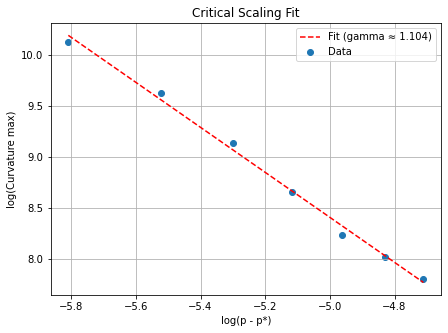

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# INPUT DATA
# ---------------------------
curvature = np.array([
    2429.599863,
    3018.903167,
    3762.686009,
    5745.299868,
    9287.641128,
    15188.59489,
    24935.63771
])

p_minus_pstar = np.array([
    0.009,
    0.008,
    0.007,
    0.006,
    0.005,
    0.004,
    0.003
])

pstar = 4.110

# reconstruct actual p
p = pstar + p_minus_pstar

# ---------------------------
# LOG-LOG FIT
# ---------------------------
log_x = np.log(p - pstar)
log_y = np.log(curvature)

coeffs = np.polyfit(log_x, log_y, 1)
slope, intercept = coeffs

gamma = -slope / 2

print("===== RESULTS =====")
print(f"Slope = {slope}")
print(f"Gamma = {gamma}")

# ---------------------------
# FIT LINE FOR PLOT
# ---------------------------
x_fit = np.linspace(min(log_x), max(log_x), 100)
y_fit = slope * x_fit + intercept

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

plt.scatter(log_x, log_y, label="Data")
plt.plot(x_fit, y_fit, 'r--', label=f"Fit (gamma ≈ {gamma:.3f})")

plt.xlabel("log(p - p*)")
plt.ylabel("log(Curvature max)")
plt.title("Critical Scaling Fit")
plt.legend()
plt.grid()

plt.show()

===== SUBCRITICAL RESULTS =====
Gamma = 0.55225 ± 0.31845
R^2   = 0.99473


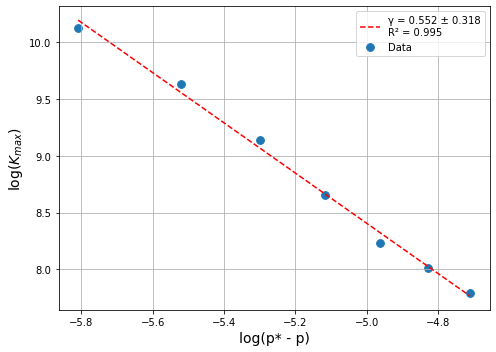

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# INPUT DATA
# ---------------------------
curvature = np.array([
    2429.599863,
    3018.903167,
    3762.686009,
    5745.299868,
    9287.641128,
    15188.59489,
    24935.63771
])

p_minus_pstar = np.array([
    0.009,
    0.008,
    0.007,
    0.006,
    0.005,
    0.004,
    0.003
])

pstar = 4.110
dpstar = 0.003

# reconstruct actual p (subcritical → p < p*)
p = pstar - p_minus_pstar

# ---------------------------
# FUNCTION: gamma + R²
# ---------------------------
def compute_gamma(pstar_val):
    delta = pstar_val - p   # (p* - p)
    
    mask = delta > 0
    
    x = np.log(delta[mask])
    y = np.log(curvature[mask])
    
    if len(x) < 2:
        return np.nan, None, None
    
    slope, intercept = np.polyfit(x, y, 1)
    gamma = -slope / 4
    
    # R²
    y_fit = slope * x + intercept
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot
    
    return gamma, slope, r2

# ---------------------------
# CENTRAL VALUE
# ---------------------------
gamma_c, slope_c, r2_c = compute_gamma(pstar)

# ---------------------------
# ERROR FROM p*
# ---------------------------
gamma_plus, _, _ = compute_gamma(pstar + dpstar)
gamma_minus, _, _ = compute_gamma(pstar - dpstar)

valid = [g for g in [gamma_plus, gamma_minus] if not np.isnan(g)]
gamma_err = max(abs(g - gamma_c) for g in valid)

# ---------------------------
# FINAL FIT (central)
# ---------------------------
log_x = np.log(p_minus_pstar)
log_y = np.log(curvature)

slope, intercept = np.polyfit(log_x, log_y, 1)

x_fit = np.linspace(min(log_x), max(log_x), 100)
y_fit = slope * x_fit + intercept

# ---------------------------
# PRINT RESULTS
# ---------------------------
print("===== SUBCRITICAL RESULTS =====")
print(f"Gamma = {gamma_c:.5f} ± {gamma_err:.5f}")
print(f"R^2   = {r2_c:.5f}")

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

plt.scatter(log_x, log_y, s=60, label="Data")
plt.plot(x_fit, y_fit, 'r--',
         label=f"γ = {gamma_c:.3f} ± {gamma_err:.3f}\nR² = {r2_c:.3f}")

plt.xlabel("log(p* - p)",fontsize=14)
plt.ylabel("$\log(K_{max})$",fontsize=14)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("plusfamily.pdf")
plt.show()
